# SolarDrive — All Paper Figures

Generates every figure from the paper. The feature comparison table (formerly
Fig 1) is now Table I in the paper and is not reproduced here.

| Cell | Figure | Paper reference |
|---|---|---|
| 1 | GPU check | — |
| 2 | Mount Drive + unzip dataset | — |
| 3 | Install dependencies | — |
| 4 | **Fig 1** — Geographical Map of Tartu routes | Fig. 1 |
| 5 | **Fig 2** — Dataset Diversity (2×4 grid) | Fig. 2 |
| 6 | **Fig 3** — Logarithmic Pixel Intensity Histograms | Fig. 3 |
| 7 | **Fig 4** — Confidence vs Brightness (YOLOv8x) | Fig. 4 |
| 8 | **Fig 5** — Transient Blindness — Object Loss & Recovery | Fig. 5 |
| 9 | **Fig 6** — FFT Temporal Stability (stroboscopic flicker) | Fig. 6 |
| 10 | **Fig 7** — Stroboscopic Flicker Frame Triplets | Fig. 7 |
| 11 | List all saved outputs | — |

**Drive layout expected:**
```
MyDrive/
  SolarDrive_dataset.zip   ← images archive
  SolarDrive_labels.zip             ← labels archive
  solardrive_figures/    ← output folder (created automatically)
```

**Before running:** `Runtime → Change runtime type → T4 GPU`  
**Run order:** Cells 1 → 11 in order. ~50–70 min total.

---

## Cell 1 — Verify GPU

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA   :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))
    print('VRAM   :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    raise RuntimeError('No GPU — Runtime → Change runtime type → T4 GPU')

PyTorch: 2.10.0+cu128
CUDA   : True
GPU    : Tesla T4
VRAM   : 15.6 GB


## Cell 2 — Mount Drive & Unzip Dataset

All paths are fixed to the standard Drive layout. Edit the two zip paths below
if your files are stored in a subfolder.

In [2]:
from google.colab import drive
import os, glob, shutil, subprocess

drive.mount('/content/drive')

# ── Edit these two paths if needed ───────────────────────────────────────────
IMAGES_ZIP = '/content/drive/MyDrive/SolarDrive_dataset.zip'
LABELS_ZIP = '/content/drive/MyDrive/SolarDrive_labels.zip'
# ─────────────────────────────────────────────────────────────────────────────

DATASET   = '/content/SolarDrive_dataset'
DRIVE_OUT = '/content/drive/MyDrive/solardrive_figures'
SEQS      = ['sun_glare_0', 'sun_glare_1', 'sun_glare_2', 'sun_glare_3']

os.makedirs(DATASET,   exist_ok=True)
os.makedirs(DRIVE_OUT, exist_ok=True)

if not os.path.exists(f'{DATASET}/images'):
    print('Unzipping images ...')
    shutil.copy(IMAGES_ZIP, '/content/SolarDrive_dataset.zip')
    os.system('unzip -q /content/SolarDrive_dataset.zip -d /content/')
    result = subprocess.run(
        ['unzip', '-Z', '-1', '/content/SolarDrive_dataset.zip'],
        capture_output=True, text=True
    )
    top_folder = result.stdout.strip().split('\n')[0].split('/')[0]
    extracted = f'/content/{top_folder}'
    if top_folder and extracted != DATASET and os.path.exists(extracted):
        print(f'Renaming extracted folder: {top_folder} → SolarDrive_dataset')
        os.rename(extracted, DATASET)
    print('Done.')
else:
    print('Images already unzipped.')

if not os.path.exists(f'{DATASET}/labels'):
    print('Unzipping labels ...')
    shutil.copy(LABELS_ZIP, '/content/SolarDrive_labels.zip')
    os.system(f'unzip -q /content/SolarDrive_labels.zip -d {DATASET}/')
    print('Done.')
else:
    print('Labels already unzipped.')

def find_img_dir(seq):
    for path in [
        f'{DATASET}/images/{seq}/left_camera',
        f'{DATASET}/images/{seq}',
    ]:
        if os.path.isdir(path):
            return path
    return None

IMG_DIRS = {seq: find_img_dir(seq) for seq in SEQS}
all_ok   = True
for seq, d in IMG_DIRS.items():
    n  = len(glob.glob(f'{d}/*.*')) if d else 0
    ok = '✅' if d and n > 0 else '❌'
    print(f'  {ok} {seq}: {n} images at {d}')
    if not d or n == 0:
        all_ok = False

if not all_ok:
    raise RuntimeError('Missing sequences — check zip paths above.')
print('\n✅ Dataset ready.')

Mounted at /content/drive
Unzipping images ...
Renaming extracted folder: tartuglare_colab → SolarDrive_dataset
Done.
Unzipping labels ...
Done.
  ✅ sun_glare_0: 836 images at /content/SolarDrive_dataset/images/sun_glare_0/left_camera
  ✅ sun_glare_1: 247 images at /content/SolarDrive_dataset/images/sun_glare_1/left_camera
  ✅ sun_glare_2: 323 images at /content/SolarDrive_dataset/images/sun_glare_2/left_camera
  ✅ sun_glare_3: 1046 images at /content/SolarDrive_dataset/images/sun_glare_3/left_camera

✅ Dataset ready.


## Cell 3 — Install Dependencies

In [3]:
!pip install -q ultralytics seaborn scipy folium requests opencv-python-headless

import ultralytics, seaborn, scipy, folium
print('ultralytics:', ultralytics.__version__)
print('seaborn    :', seaborn.__version__)
print('scipy      :', scipy.__version__)
print('folium     :', folium.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.37
seaborn    : 0.13.2
scipy      : 1.16.3
folium     : 0.20.0


## Cell 4 — Figure 1: Geographical Map of Tartu Routes

Plots the four driving routes in Tartu, Estonia on an interactive map using
the OSRM public routing API for road-snapped polylines.
Saved as an HTML file (open in browser to view the interactive version).

**Paper Fig. 1** — Geographical overview of the SolarDrive dataset.

In [4]:
import folium
import requests

# GPS coordinates: [longitude, latitude] for OSRM; folium uses [lat, lon]
SEQ0_START = [26.716134, 58.371406]; SEQ0_END = [26.6830, 58.3577]
SEQ1_START = [26.766219, 58.371544]; SEQ1_END = [26.757522, 58.372472]
SEQ2_START = [26.7485,   58.3745  ]; SEQ2_END = [26.7397,   58.3717  ]
SEQ3_START = [26.7274,   58.3775  ]; SEQ3_END = [26.6823,   58.3571  ]

ROUTES = [
    {'id': 3, 'name': 'Route D (sun_glare_3)', 'color': '#9B59B6',
     'start': SEQ3_START, 'end': SEQ3_END, 'style': 'dashed', 'weight': 4},
    {'id': 0, 'name': 'Route A (sun_glare_0)', 'color': '#D9534F',
     'start': SEQ0_START, 'end': SEQ0_END, 'style': 'solid',  'weight': 7},
    {'id': 1, 'name': 'Route B (sun_glare_1)', 'color': '#337AB7',
     'start': SEQ1_START, 'end': SEQ1_END, 'style': 'solid',  'weight': 6},
    {'id': 2, 'name': 'Route C (sun_glare_2)', 'color': '#5CB85C',
     'start': SEQ2_START, 'end': SEQ2_END, 'style': 'solid',  'weight': 6},
]


def get_route(start, end):
    """Fetch road-snapped polyline from OSRM public API."""
    url = (
        f'http://router.project-osrm.org/route/v1/driving/'
        f'{start[0]},{start[1]};{end[0]},{end[1]}'
        f'?overview=full&geometries=geojson'
    )
    try:
        data   = requests.get(url, timeout=10).json()
        coords = data['routes'][0]['geometry']['coordinates']
        return [[lat, lon] for lon, lat in coords]
    except Exception:
        # Fall back to straight line if API unreachable
        return [[start[1], start[0]], [end[1], end[0]]]


m = folium.Map(location=[58.370, 26.720], zoom_start=13, tiles='CartoDB positron')

for r in ROUTES:
    path = get_route(r['start'], r['end'])
    folium.PolyLine(
        path,
        color      = r['color'],
        weight     = r['weight'],
        opacity    = 0.8 if r['style'] == 'solid' else 0.6,
        dash_array = None if r['style'] == 'solid' else '10,10',
        tooltip    = r['name'],
    ).add_to(m)
    # Start marker
    folium.CircleMarker(
        [r['start'][1], r['start'][0]],
        radius=4, color=r['color'], fill=True, fill_opacity=1,
        tooltip=f"{r['name']} — start",
    ).add_to(m)
    # End marker
    folium.CircleMarker(
        [r['end'][1], r['end'][0]],
        radius=4, color=r['color'], fill=True, fill_opacity=0.5,
        tooltip=f"{r['name']} — end",
    ).add_to(m)

# Solar azimuth annotation
folium.Marker(
    [58.362, 26.668],
    icon=folium.DivIcon(
        html='<div style="font-size:11px;color:#333;white-space:nowrap;">'
             'Solar Azimuth (≈270°)</div>'
    ),
).add_to(m)

OUT = f'{DRIVE_OUT}/figure1_map.html'
m.save(OUT)
print(f'✅ Saved: {OUT}')
print('  Open the HTML file in a browser to view the interactive map.')

✅ Saved: /content/drive/MyDrive/solardrive_figures/figure1_map.html
  Open the HTML file in a browser to view the interactive map.


## Cell 5 — Figure 2: Dataset Diversity (2×4 Grid)

Top row: one representative frame per sequence, selected by maximising local
contrast variance (algorithmic selection — avoids complete washout).
Bottom row: manually selected frames highlighting specific geometric challenges.

**Paper Fig. 2** — Dataset Diversity.

✅ Saved: /content/drive/MyDrive/solardrive_figures/figure2_dataset_diversity.png


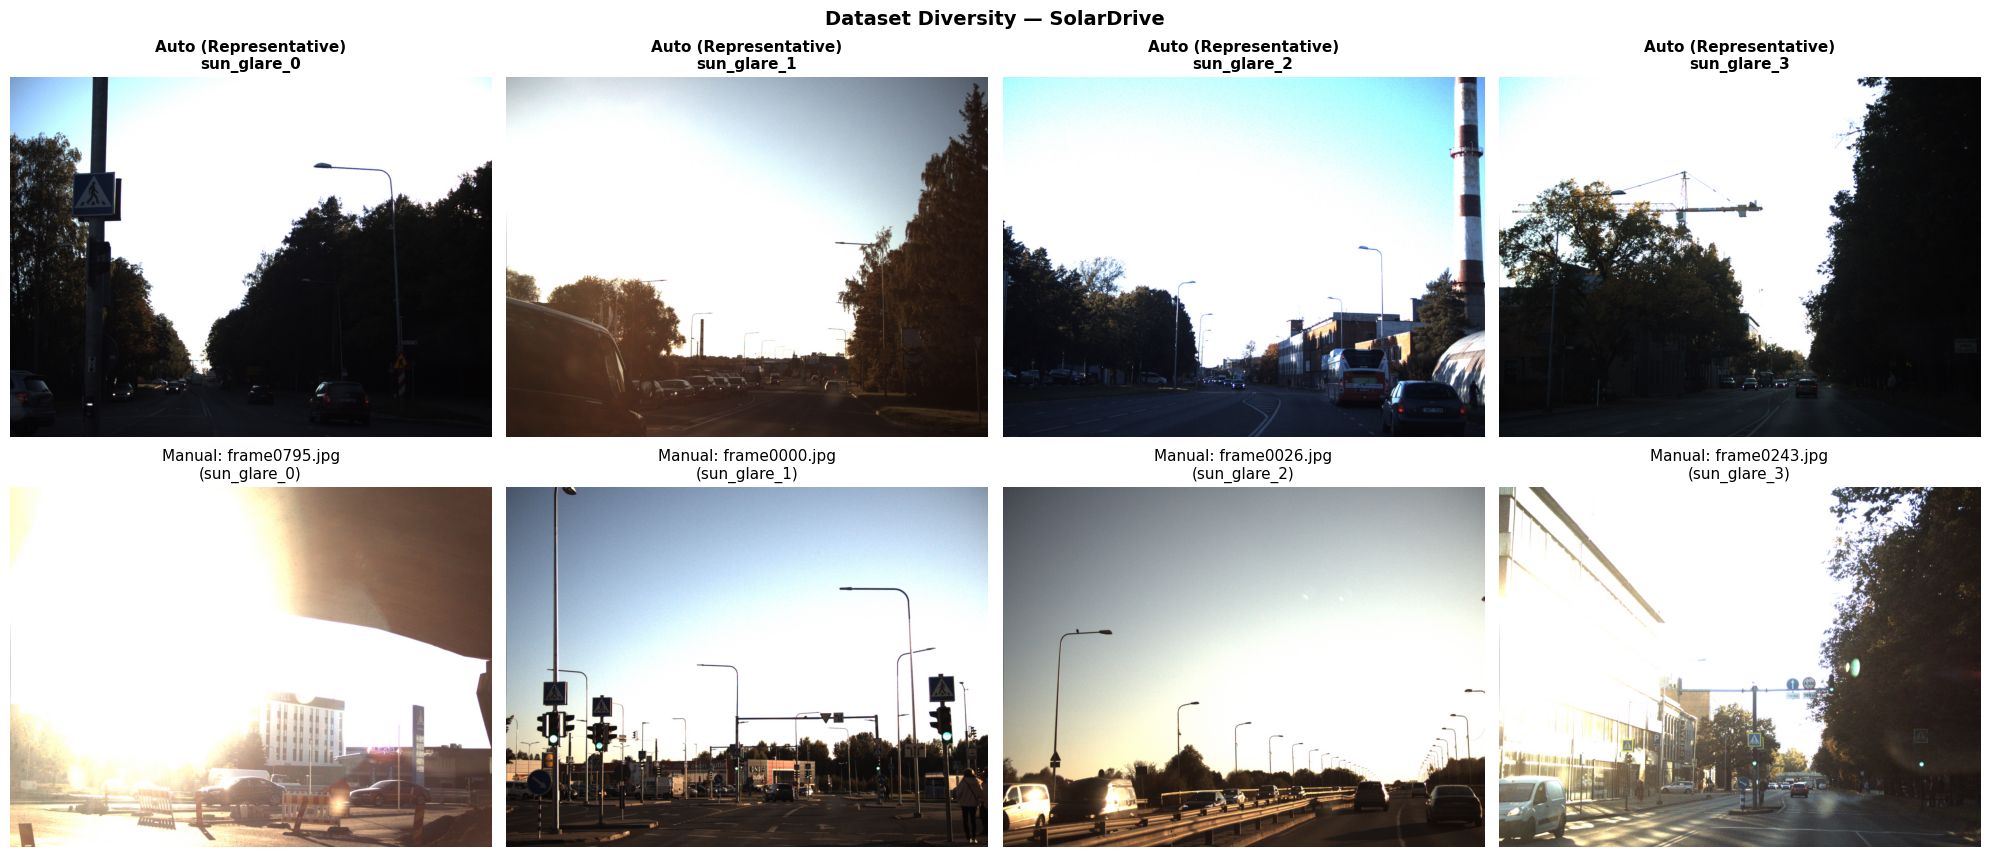

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Manually selected frames that best illustrate geometric challenges
# (Section III.D — frame0795: direct solar bloom; frame0026: specular asphalt;
#  frame0243: simultaneous bloom + canopy shadow)
MANUAL = {
    'sun_glare_0': 'frame0795.jpg',
    'sun_glare_1': 'frame0000.jpg',
    'sun_glare_2': 'frame0026.jpg',
    'sun_glare_3': 'frame0243.jpg',
}


def get_balanced_frame(seq):
    """Select the frame with highest contrast variance, penalising fully blown/dark frames."""
    img_dir = IMG_DIRS[seq]
    if not img_dir or not os.path.isdir(img_dir):
        return np.zeros((640, 640, 3), dtype=np.uint8)
    files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])[::50]
    best_img, best_score = None, -1
    for f in files:
        img = cv2.imread(os.path.join(img_dir, f))
        if img is None:
            continue
        gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mean_b  = np.mean(gray)
        penalty = 0.2 if mean_b > 230 or mean_b < 30 else 1.0
        score   = np.std(gray) * penalty
        if score > best_score:
            best_score = score
            best_img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return best_img if best_img is not None else np.zeros((640, 640, 3), dtype=np.uint8)


def get_manual_frame(seq, target):
    img_dir = IMG_DIRS[seq]
    if not img_dir:
        return np.zeros((640, 640, 3), dtype=np.uint8)
    path = os.path.join(img_dir, target)
    if os.path.exists(path):
        return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    # Fallback: partial name match
    for f in os.listdir(img_dir):
        if target in f:
            return cv2.cvtColor(cv2.imread(os.path.join(img_dir, f)), cv2.COLOR_BGR2RGB)
    return np.zeros((640, 640, 3), dtype=np.uint8)


fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, seq in enumerate(SEQS):
    img = get_balanced_frame(seq)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Auto (Representative)\n{seq}', fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

for i, seq in enumerate(SEQS):
    img = get_manual_frame(seq, MANUAL[seq])
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Manual: {MANUAL[seq]}\n({seq})', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Dataset Diversity — SolarDrive', fontsize=14, fontweight='bold')
plt.tight_layout()
OUT = f'{DRIVE_OUT}/figure2_dataset_diversity.png'
plt.savefig(OUT, dpi=300, bbox_inches='tight')
print(f'✅ Saved: {OUT}')

## Cell 6 — Figure 3: Logarithmic Pixel Intensity Histograms

Aggregates pixel intensity distributions across 50 randomly sampled frames per
sequence. Log-scale y-axis exposes the extreme tails (shadow crushing at 0–9
and highlight saturation at 245–255) that RIL quantifies.

**Paper Fig. 3** — Photometric Failure: Pixel Intensity Distribution.

Histogram stats:
  sun_glare_0: shadows=2.65%  highlights=26.29%
  sun_glare_1: shadows=0.28%  highlights=31.47%
  sun_glare_2: shadows=0.94%  highlights=25.96%
  sun_glare_3: shadows=0.98%  highlights=36.25%

✅ Saved: /content/drive/MyDrive/solardrive_figures/figure3_histograms.png


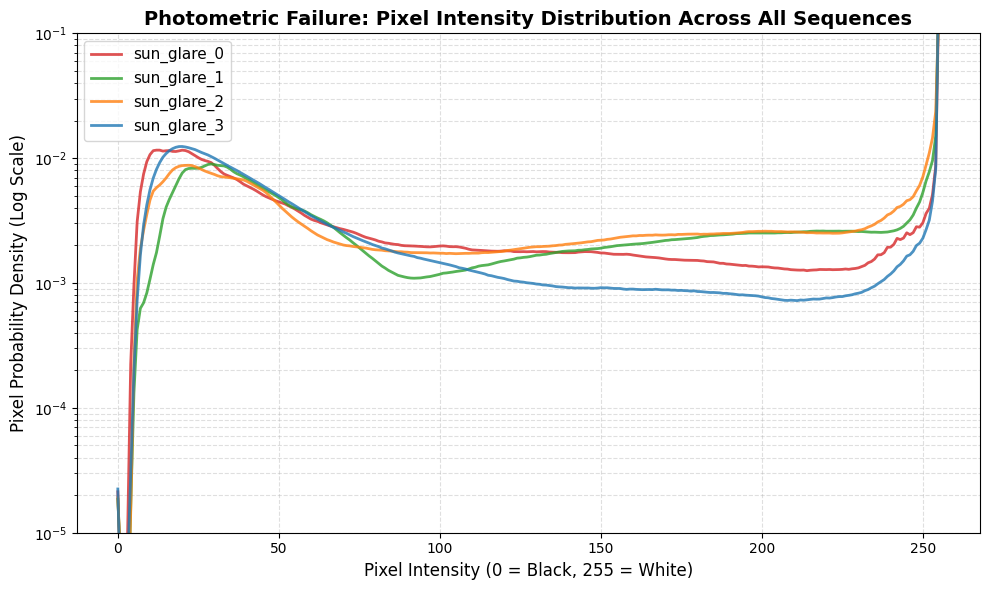

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

COLORS = {
    'sun_glare_0': '#d62728',
    'sun_glare_1': '#2ca02c',
    'sun_glare_2': '#ff7f0e',
    'sun_glare_3': '#1f77b4',
}

plt.figure(figsize=(10, 6))
results = []

for seq in SEQS:
    img_dir = IMG_DIRS[seq]
    if not img_dir or not os.path.isdir(img_dir):
        print(f'  ❌ {seq} not found')
        continue
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
    np.random.seed(42)
    sample   = np.random.choice(img_files, min(50, len(img_files)), replace=False)
    agg_hist = np.zeros((256, 1))
    for fname in sample:
        img = cv2.imread(os.path.join(img_dir, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            agg_hist += cv2.calcHist([img], [0], None, [256], [0, 256])
    agg_hist      /= np.sum(agg_hist)
    shadow_pct     = float(np.sum(agg_hist[0:10])    * 100)
    highlight_pct  = float(np.sum(agg_hist[245:256]) * 100)
    results.append(f'  {seq}: shadows={shadow_pct:.2f}%  highlights={highlight_pct:.2f}%')
    plt.plot(agg_hist, color=COLORS[seq], label=seq, linewidth=2, alpha=0.8)

plt.yscale('log')
plt.ylim(bottom=1e-5, top=1e-1)
plt.title(
    'Photometric Failure: Pixel Intensity Distribution Across All Sequences',
    fontsize=14, fontweight='bold',
)
plt.xlabel('Pixel Intensity (0 = Black, 255 = White)', fontsize=12)
plt.ylabel('Pixel Probability Density (Log Scale)', fontsize=12)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
OUT = f'{DRIVE_OUT}/figure3_histograms.png'
plt.savefig(OUT, dpi=300)
print('Histogram stats:')
for r in results:
    print(r)
print(f'\n✅ Saved: {OUT}')

## Cell 7 — Figure 4: Detection Confidence vs Frame Brightness (YOLOv8x)

Samples ~50 evenly spaced frames per sequence, runs YOLOv8x on each, and
plots the mean bounding box confidence against mean HSV V-channel brightness.
The heteroscedastic scatter above V=160 demonstrates that global illumination
alone cannot predict detection failure.

**Paper Fig. 4** — YOLO confidence vs mean frame brightness.

Loading yolov8x.pt ...
  Processing sun_glare_0 ...
  Processing sun_glare_1 ...
  Processing sun_glare_2 ...
  Processing sun_glare_3 ...
  Collected 219 data points
✅ Saved: /content/drive/MyDrive/solardrive_figures/figure4_confidence_vs_brightness.png


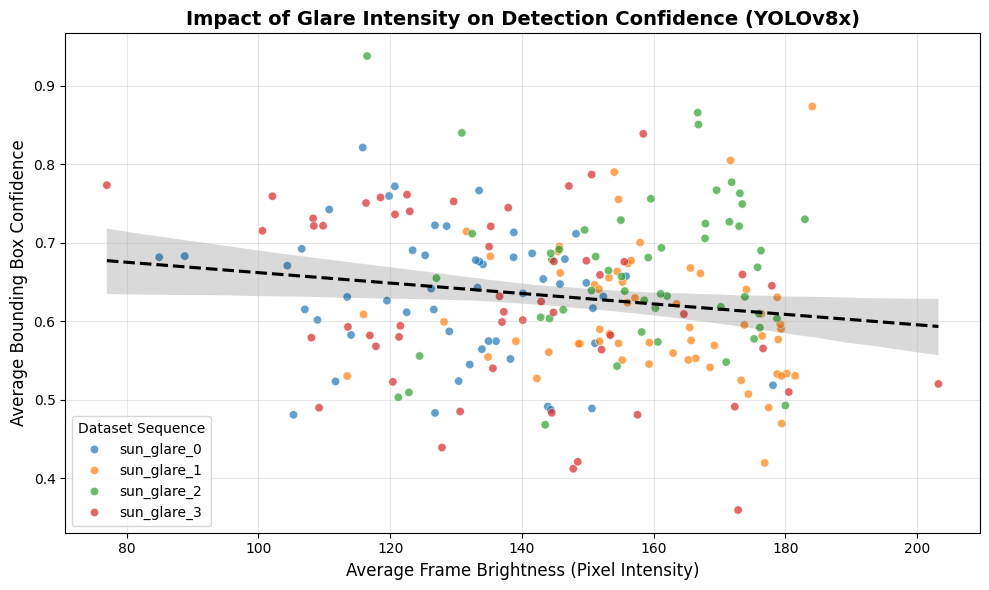

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

MODEL_PATH = 'yolov8x.pt'
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'

print(f'Loading {MODEL_PATH} ...')
model        = YOLO(MODEL_PATH)
scatter_data = []

for seq in SEQS:
    print(f'  Processing {seq} ...')
    img_dir = IMG_DIRS[seq]
    if not img_dir or not os.path.isdir(img_dir):
        print(f'    ❌ Not found')
        continue
    frames = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])
    step   = max(1, len(frames) // 50)
    for f in frames[::step]:
        fpath = os.path.join(img_dir, f)
        img   = cv2.imread(fpath)
        if img is None:
            continue
        hsv        = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        brightness = float(np.mean(hsv[:, :, 2]))
        res        = model(fpath, verbose=False, device=DEVICE)[0]
        if len(res.boxes) > 0:
            # Filter to conf ≥ 0.25 before averaging — removes spurious
            # near-zero detections that would pull the mean down
            conf_thresh = 0.25
            mask   = res.boxes.conf >= conf_thresh
            confs  = res.boxes.conf[mask]
            if len(confs) > 0:
                scatter_data.append({
                    'Brightness': brightness,
                    'Confidence': float(confs.mean()),
                    'Sequence':   seq,
                })

del model
torch.cuda.empty_cache()

df = pd.DataFrame(scatter_data)
print(f'  Collected {len(df)} data points')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Brightness', y='Confidence',
                hue='Sequence', palette='tab10', alpha=0.7)
sns.regplot(data=df, x='Brightness', y='Confidence',
            scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('Impact of Glare Intensity on Detection Confidence (YOLOv8x)',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Frame Brightness (Pixel Intensity)', fontsize=12)
plt.ylabel('Average Bounding Box Confidence', fontsize=12)
plt.legend(title='Dataset Sequence', loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
OUT = f'{DRIVE_OUT}/figure4_confidence_vs_brightness.png'
plt.savefig(OUT, dpi=300)
print(f'✅ Saved: {OUT}')

## Cell 8 — Figure 5: Transient Blindness — Object Loss & Recovery

Runs YOLO11x on four consecutive frames from sun_glare_0 (frames 0145–0148)
to illustrate the transient blindness failure mode: a vehicle is detected at
T, lost at T+1 and T+2 as pixel intensities saturate, then re-detected at
T+3 — by which point the tracker's `max_age` has expired, forcing an ID switch.

**Paper Fig. 5** — Transient Blindness (sun_glare_0).

Loading yolo11x.pt ...
✅ Saved: /content/drive/MyDrive/solardrive_figures/figure5_transient_blindness.png


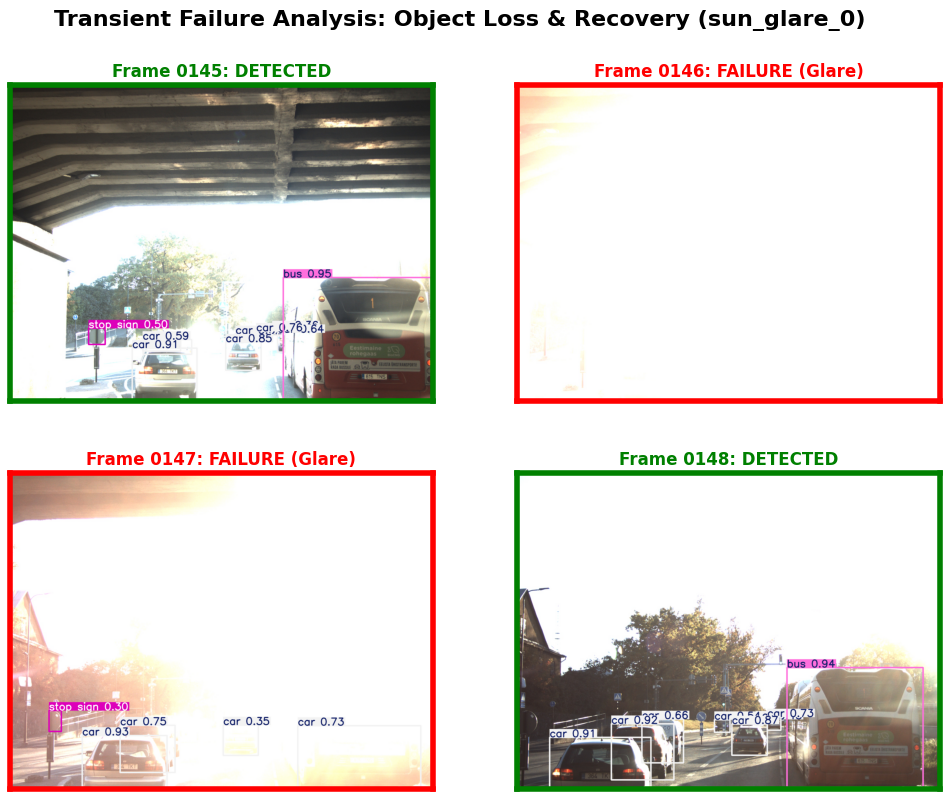

In [8]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

SEQUENCE   = 'sun_glare_0'
FRAME_IDS  = ['0145', '0146', '0147', '0148']
MODEL_NAME = 'yolo11x.pt'
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'
img_dir    = IMG_DIRS[SEQUENCE]


def get_frame_path(frame_id):
    """Find a frame by its numeric ID regardless of filename prefix."""
    for ext in ['.jpg', '.png', '.jpeg']:
        for prefix in ['frame', 'frame_', '']:
            p = os.path.join(img_dir, f'{prefix}{frame_id}{ext}')
            if os.path.exists(p):
                return p
    return None


print(f'Loading {MODEL_NAME} ...')
model = YOLO(MODEL_NAME)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes  = axes.flatten()
found = False

for i, fid in enumerate(FRAME_IDS):
    ax   = axes[i]
    path = get_frame_path(fid)
    if path:
        found   = True
        res     = model(path, verbose=False, device=DEVICE)
        img_rgb = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        # Frames 1 and 2 (0146, 0147) are the glare failure frames
        status = 'FAILURE (Glare)' if i in [1, 2] else 'DETECTED'
        color  = 'red'             if i in [1, 2] else 'green'
        ax.set_title(f'Frame {fid}: {status}', fontsize=12, fontweight='bold', color=color)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)
    else:
        ax.text(0.5, 0.5, f'Frame {fid}\nnot found',
                ha='center', va='center', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

del model
torch.cuda.empty_cache()

if found:
    plt.suptitle(
        f'Transient Failure Analysis: Object Loss & Recovery ({SEQUENCE})',
        fontsize=16, fontweight='bold',
    )
    plt.subplots_adjust(top=0.90)
    OUT = f'{DRIVE_OUT}/figure5_transient_blindness.png'
    plt.savefig(OUT, dpi=300, bbox_inches='tight')
    print(f'✅ Saved: {OUT}')
else:
    print('❌ No frames found — check DATASET path and frame naming.')

## Cell 9 — Figure 6: FFT Temporal Stability Analysis

Plots mean pixel intensity over time for up to 300 frames per sequence (shorter sequences use all remaining frames), with
detected brightness peaks (flashes) marked in red. The dominant oscillation
frequency is computed as: `n_peaks / (window_duration_in_seconds)`.

**Paper Fig. 6** — Temporal Photometric Stability Across Sequences.  
Key finding: sun_glare_0 (3.20 Hz) and sun_glare_3 (2.20 Hz) exhibit severe
stroboscopic oscillations driven by alternating tree canopy and direct solar
alignment.

  Processing sun_glare_0 ...
  Processing sun_glare_1 ...
  Processing sun_glare_2 ...
  Processing sun_glare_3 ...

Flicker summary:
  sun_glare_0: 32 flashes  3.20 Hz
  sun_glare_1: 9 flashes  1.45 Hz
  sun_glare_2: 18 flashes  2.22 Hz
  sun_glare_3: 22 flashes  2.20 Hz

✅ Saved: /content/drive/MyDrive/solardrive_figures/figure6_fft_flicker.png


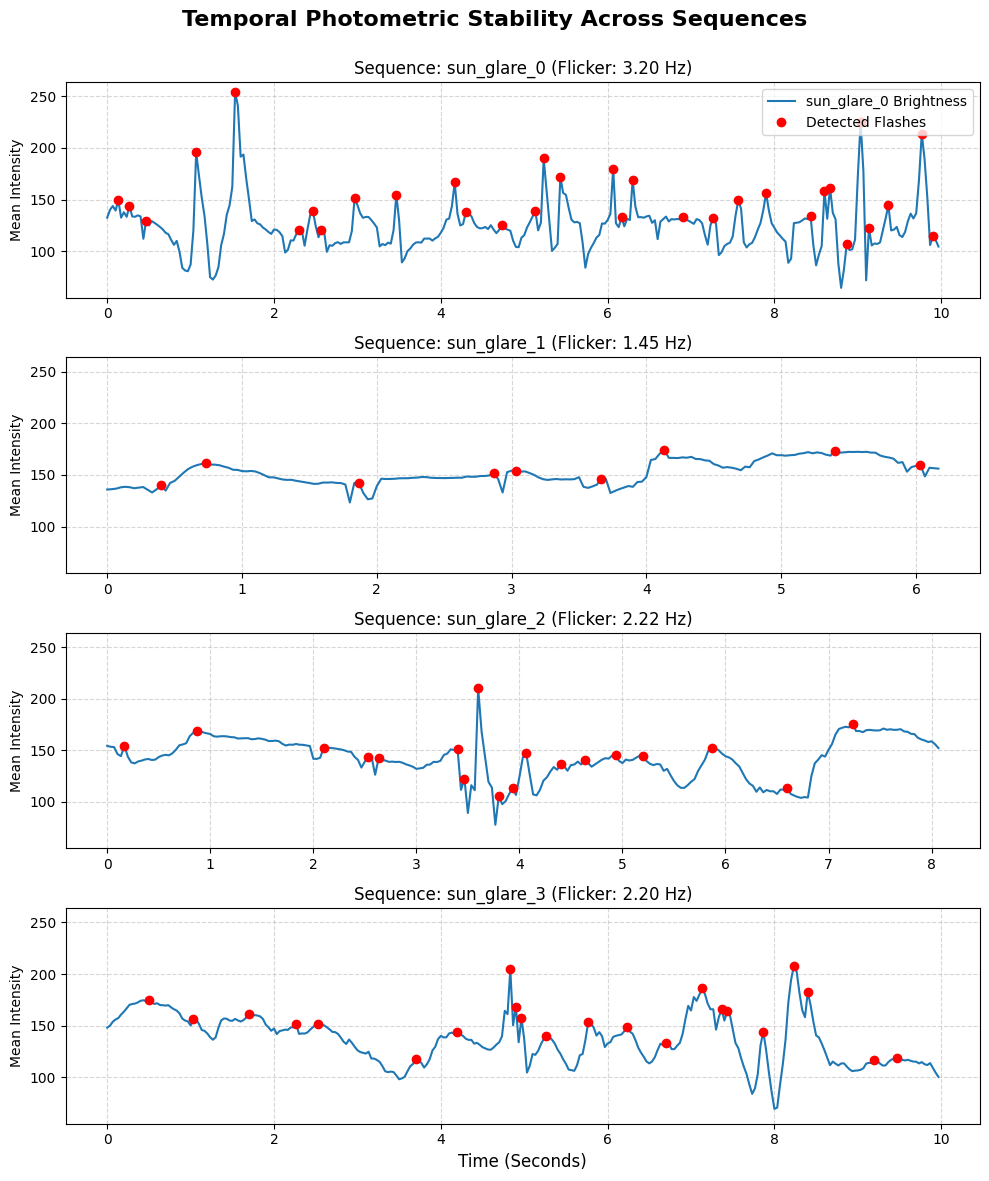

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

FPS = 30.0

fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharey=True)
fig.suptitle('Temporal Photometric Stability Across Sequences',
             fontsize=16, fontweight='bold')
flicker_log = []

for idx, seq in enumerate(SEQS):
    print(f'  Processing {seq} ...')
    img_dir = IMG_DIRS[seq]
    if not img_dir or not os.path.isdir(img_dir):
        print(f'    ❌ Not found')
        continue

    files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])
    # Use up to 300 frames starting at 25% into the sequence to avoid cold-start AE
    # (shorter sequences use their full remaining length — Hz values remain correct)
    start = min(100, len(files) // 4)
    end   = min(start + 300, len(files))

    brightness = []
    for i in range(start, end):
        img = cv2.imread(os.path.join(img_dir, files[i]), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            brightness.append(float(np.mean(img)))

    b_arr    = np.array(brightness)
    peaks, _ = find_peaks(b_arr, distance=2, prominence=5)
    freq     = len(peaks) / (len(b_arr) / FPS)
    flicker_log.append(f'  {seq}: {len(peaks)} flashes  {freq:.2f} Hz')

    t = np.arange(len(b_arr)) / FPS
    axs[idx].plot(t, b_arr, color='#1f77b4', linewidth=1.5,
                  label=f'{seq} Brightness')
    axs[idx].plot(t[peaks], b_arr[peaks], 'ro', label='Detected Flashes')
    axs[idx].set_title(f'Sequence: {seq} (Flicker: {freq:.2f} Hz)', fontsize=12)
    axs[idx].set_ylabel('Mean Intensity')
    axs[idx].grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        axs[idx].legend(loc='upper right')

axs[-1].set_xlabel('Time (Seconds)', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
OUT = f'{DRIVE_OUT}/figure6_fft_flicker.png'
plt.savefig(OUT, dpi=300)
print('\nFlicker summary:')
for r in flicker_log:
    print(r)
print(f'\n✅ Saved: {OUT}')

## Cell 10 — Figure 7: Stroboscopic Flicker Frame Triplets

Shows two tree-gap flicker events from sun_glare_3 — each a before/during/after
triplet. The middle frame (GLARE) demonstrates how target pixels saturate to
I→255 within a single frame, resetting spatial IoU to zero and corrupting
ReID embeddings.

Frame indices 608/609/610 and 629/630/631 are zero-indexed into the sorted
file list for sun_glare_3.

**Paper Fig. 7** — Qualitative demonstration of stroboscopic flicker.

✅ Saved: /content/drive/MyDrive/solardrive_figures/figure7_stroboscopic_flicker.png


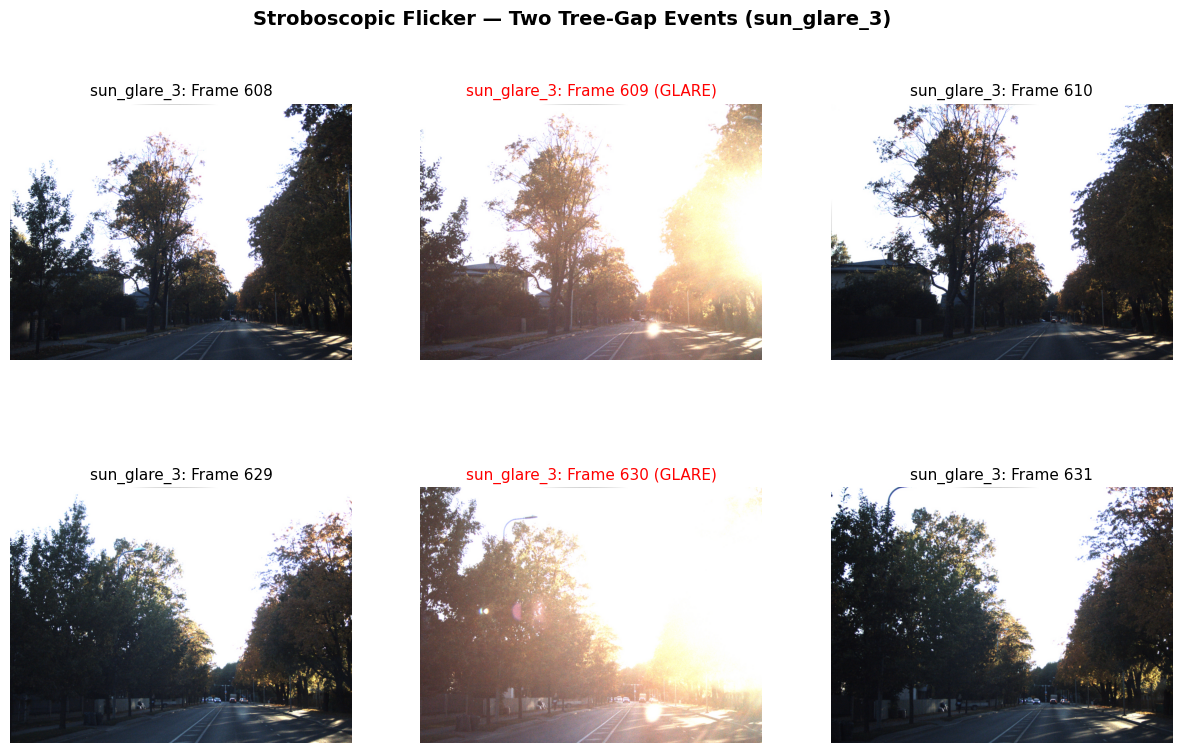

In [10]:
import os
import cv2
import matplotlib.pyplot as plt


def get_frames(seq, frame_numbers):
    """Load frames by zero-based index from the sorted file list."""
    img_dir = IMG_DIRS[seq]
    if not img_dir or not os.path.isdir(img_dir):
        return []
    files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))])
    imgs  = []
    for n in frame_numbers:
        if n < len(files):
            img = cv2.imread(os.path.join(img_dir, files[n]))
            if img is not None:
                imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    return imgs


fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Event 1: frames 608 (before), 609 (glare), 610 (after)
event1  = get_frames('sun_glare_3', [608, 609, 610])
labels1 = ['Frame 608', 'Frame 609 (GLARE)', 'Frame 610']
for i, img in enumerate(event1[:3]):
    axes[0, i].imshow(img)
    axes[0, i].set_title(
        f'sun_glare_3: {labels1[i]}', fontsize=11,
        color='red' if i == 1 else 'black',
    )
    axes[0, i].axis('off')
    if i == 1:
        for sp in axes[0, i].spines.values():
            sp.set_edgecolor('red'); sp.set_linewidth(3); sp.set_visible(True)

# Event 2: frames 629 (before), 630 (glare), 631 (after)
event2  = get_frames('sun_glare_3', [629, 630, 631])
labels2 = ['Frame 629', 'Frame 630 (GLARE)', 'Frame 631']
for i, img in enumerate(event2[:3]):
    axes[1, i].imshow(img)
    axes[1, i].set_title(
        f'sun_glare_3: {labels2[i]}', fontsize=11,
        color='red' if i == 1 else 'black',
    )
    axes[1, i].axis('off')
    if i == 1:
        for sp in axes[1, i].spines.values():
            sp.set_edgecolor('red'); sp.set_linewidth(3); sp.set_visible(True)

plt.suptitle('Stroboscopic Flicker — Two Tree-Gap Events (sun_glare_3)',
             fontsize=14, fontweight='bold')
plt.subplots_adjust(top=0.93, hspace=0.08)
OUT = f'{DRIVE_OUT}/figure7_stroboscopic_flicker.png'
plt.savefig(OUT, dpi=300, bbox_inches='tight')
print(f'✅ Saved: {OUT}')

## Cell 11 — List All Saved Figures

In [11]:
import os, glob

files = sorted(glob.glob(f'{DRIVE_OUT}/*'))
print(f'Figures saved to: {DRIVE_OUT}/')
print()
for fpath in files:
    size = os.path.getsize(fpath) / 1024
    print(f'  {os.path.basename(fpath):<50}  {size:>8.1f} KB')
print(f'\n✅ All {len(files)} file(s) ready in Google Drive.')

Figures saved to: /content/drive/MyDrive/solardrive_figures/

  RIL_results.txt                                          0.7 KB
  dataset_statistics.txt                                   0.7 KB
  figure1_map.html                                        20.9 KB
  figure2_dataset_diversity.png                        13187.8 KB
  figure3_histograms.png                                 331.8 KB
  figure4_confidence_vs_brightness.png                   341.4 KB
  figure5_transient_blindness.png                       2898.2 KB
  figure6_fft_flicker.png                                620.5 KB
  figure7_stroboscopic_flicker.png                      7161.6 KB
  tartuglare_mot_coco.json                              2121.1 KB

✅ All 10 file(s) ready in Google Drive.
